# Low-Light Enhancement & Detection

Pipeline: **Enhance → Segment → Clean → Detect → Decide**

Run: **Kernel → Restart & Run All**

## Step 0 — Setup

In [7]:
%matplotlib inline

import sys
from pathlib import Path

if Path("/content").exists():
    ROOT = Path("/content/TEAMproject")
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import random, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from lowlight_cv.config import DEFAULT_SEED, SHOWCASE_DIR
from lowlight_cv.data import load_real_test_images
from lowlight_cv.enhancement.methods import ENHANCERS
from lowlight_cv.io.export import make_pipeline_strip
from lowlight_cv.pipeline import LowLightPipeline

random.seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)
SHOWCASE_DIR.mkdir(parents=True, exist_ok=True)

## Step 1 — Dataset

Real low-light images from the LOL dataset.

In [ ]:
records, stats = load_real_test_images(6)
print(f"LOL: {stats['lol']}  custom: {stats['custom']}")

low0 = records[0]["low"]
high0 = records[0].get("high")

ncols = 2 if high0 is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))
if ncols == 1:
    axes = [axes]
axes[0].imshow(cv2.cvtColor(low0, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input (low-light)")
axes[0].axis("off")
if high0 is not None:
    axes[1].imshow(cv2.cvtColor(high0, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Reference")
    axes[1].axis("off")
plt.show()

## Step 2 — Enhancement

Stage 1: compare low-light correction methods.

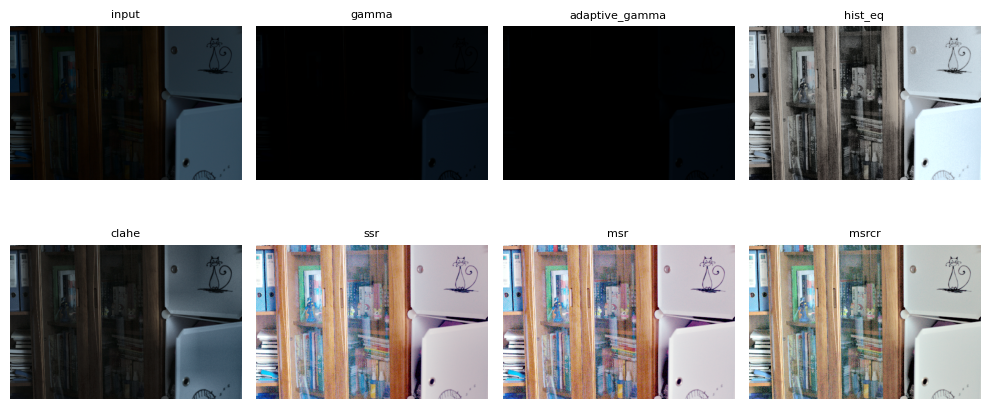

In [ ]:
names = ["input"] + list(ENHANCERS.keys())
imgs = [low0] + [fn(low0) for fn in ENHANCERS.values()]
cols, rows = 4, int(np.ceil(len(imgs) / 4))
plt.figure(figsize=(cols * 2.5, rows * 2.5))
for i, (img, title) in enumerate(zip(imgs, names)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 3 — Full pipeline

Detect salient regions after enhancement (bounding boxes + scene decision).

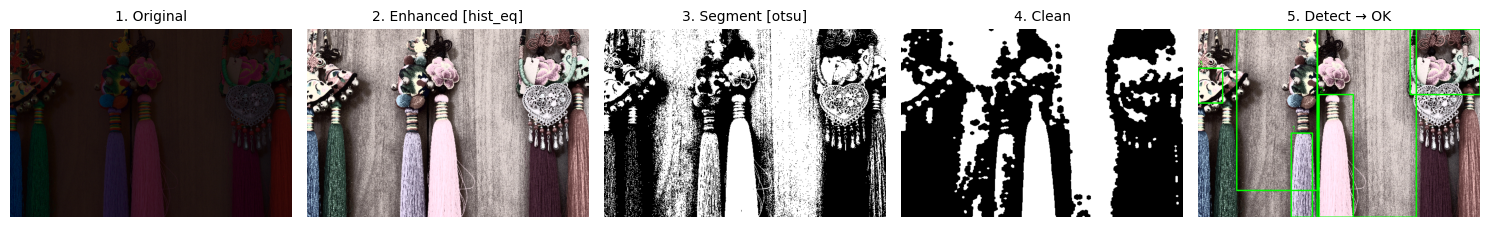

{
  "count": 6,
  "coverage": 0.375,
  "status": "objects_detected",
  "load": "medium",
  "label": "OK",
  "alert": false,
  "message": "Scene OK: 6 region(s) detected (37.5% coverage).",
  "enhancer": "hist_eq",
  "segmenter": "otsu"
}


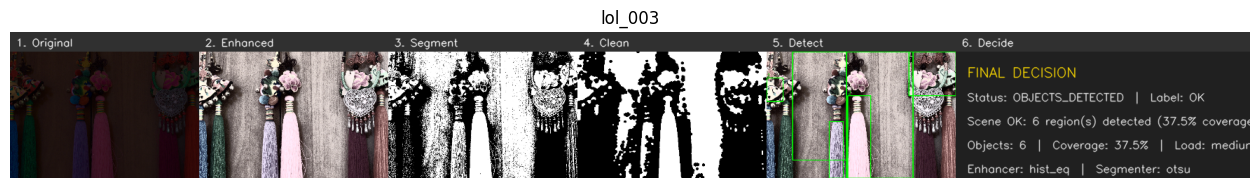

In [ ]:
pipe = LowLightPipeline(enhance="auto", segment="auto")
demo_idx = min(3, len(records) - 1)
result = pipe.process(records[demo_idx]["low"])

pipe.visualize(result)
print(json.dumps(result["decision"], indent=2))

strip = make_pipeline_strip(result, target_h=180)
plt.figure(figsize=(16, 3))
plt.imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(records[demo_idx]["name"])
plt.show()

## Step 4 — Batch run

Process 6 images and save required outputs to `outputs/showcase/`.

In [ ]:
from IPython.display import display

summary = []
for rec in records[:6]:
    r = pipe.process(rec["low"])
    pipe.export(r, SHOWCASE_DIR / rec["name"], rec["name"])
    summary.append({
        "name": rec["name"],
        "label": r["decision"]["label"],
        "count": r["decision"]["count"],
        "coverage": r["decision"]["coverage"],
        "enhancer": r["decision"]["enhancer"],
    })
display(pd.DataFrame(summary))

,name,label,count,coverage,enhancer
0,lol_000,OK,3,0.536,msrcr
1,lol_001,OK,4,0.433,hist_eq
2,lol_002,OK,4,0.441,hist_eq
3,lol_003,OK,6,0.375,hist_eq
4,lol_004,OK,1,0.461,hist_eq
5,lol_005,OK,1,0.436,hist_eq


## Step 5 — Feature detectors (optional)

Lab 08: Harris, Shi-Tomasi, FAST, ORB keypoints on the enhanced image.

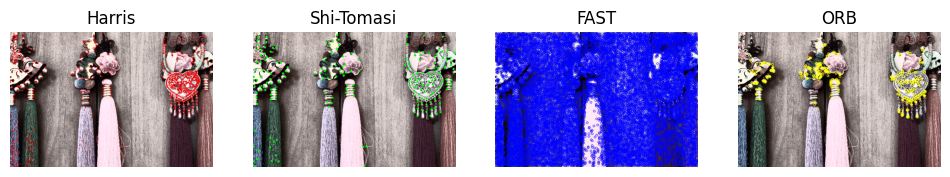

In [ ]:
from lowlight_cv.detection import fast_detect, harris, orb_detect, shi_tomasi

enh = result["enhanced"]
panels = [
    ("Harris", harris(enh)[0]),
    ("Shi-Tomasi", shi_tomasi(enh)[0]),
    ("FAST", fast_detect(enh)[0]),
    ("ORB", orb_detect(enh)[0]),
]
plt.figure(figsize=(12, 3))
for i, (title, img) in enumerate(panels, 1):
    plt.subplot(1, 4, i)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.show()